In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from black_scholes.pinn.bs_pinn_nd import BlackScholesMultiAssetPINN
from utility.model import EarlyStopping
from config.bs_nd import *


In [4]:
seed = 4
pinn = BlackScholesMultiAssetPINN(model_config, seed=seed)
pinn.set_params(K, r, sigmas, corr, T, S_mins, S_maxs)
pinn.set_loss_weights(loss_weights)

early_stopping = EarlyStopping(patience=500, min_delta=1e-7)
pinn.train(batch_size=4096, epochs=30000, early_stopping=early_stopping)

Iteration 0 | Training Loss: 0.7661349773406982 | Validation Loss: 0.6657670140266418
Iteration 500 | Training Loss: 0.04060356318950653 | Validation Loss: 0.03968659043312073
Iteration 1000 | Training Loss: 0.014888596720993519 | Validation Loss: 0.014114739373326302
Iteration 1500 | Training Loss: 0.011354448273777962 | Validation Loss: 0.011461274698376656
Iteration 2000 | Training Loss: 0.009889599867165089 | Validation Loss: 0.008851448073983192
Iteration 2500 | Training Loss: 0.007169035263359547 | Validation Loss: 0.0069371843710541725
Iteration 3000 | Training Loss: 0.006619038991630077 | Validation Loss: 0.005867028143256903
Iteration 3500 | Training Loss: 0.005152054131031036 | Validation Loss: 0.004874885082244873
Iteration 4000 | Training Loss: 0.004033393692225218 | Validation Loss: 0.004188814200460911
Iteration 4500 | Training Loss: 0.0042268382385373116 | Validation Loss: 0.0038406166713684797
Iteration 5000 | Training Loss: 0.0035850077401846647 | Validation Loss: 0.00

In [5]:
pinn.save(f'../../models/bs_pinn_nd/{seed}.pth')

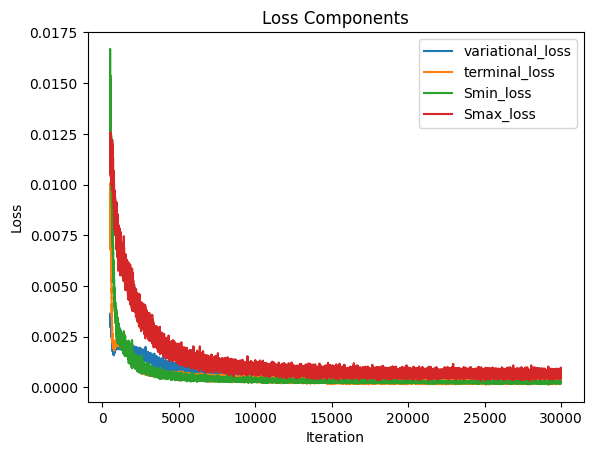

In [6]:
pinn.plot_losses(start_epoch=500, detailed=True)